# Versao 7 - Classificacao Multiclasse com LSTM Profunda

## Objetivo deste notebook

Agora treinaremos a proposta central da `versao7`: uma `LSTM` **mais profunda** do que a usada na `versao6`.

A ideia continua a mesma em alto nivel: ler a serie temporal completa (ja reamostrada para comprimento fixo) e devolver uma probabilidade para cada classe `0` a `9`. O que muda e a capacidade do modelo.

## O que o modelo faz?

Em termos conceituais:

```text
serie temporal -> LSTM profunda -> resumos temporais -> camadas densas -> softmax -> classe 0..9
```

Isso significa que a `LSTM` tentara aprender **assinaturas temporais** das classes com mais profundidade hierarquica do que antes.

## Por que aumentar a profundidade?

Porque a `versao6` mostrou um resultado metodologicamente importante:

- a `LSTM` foi boa;
- mas o `RandomForest` ainda foi melhor;
- logo, ha espaco para investigar uma rede com maior capacidade de abstracao temporal.

## O que vamos medir?

Como a base e desbalanceada, nao vamos olhar apenas `accuracy`. Tambem vamos medir:

- `macro-F1`
- `balanced accuracy`
- `matriz de confusao`

Em problemas multiclasse desbalanceados, essas metricas costumam ser mais informativas do que a acuracia isolada.

## Resultados Da Ultima Execucao Registrada

Os artefatos atuais em `artifacts/reports_v7/classificacao_v7_lstm_profunda/lstm/` mostram:

- melhor epoca: `16`
- validacao da `LSTM` profunda: `accuracy = 0.9251`, `macro-F1 = 0.8997`, `balanced accuracy = 0.9101`
- teste da `LSTM` profunda: `accuracy = 0.9104`, `macro-F1 = 0.8964`, `balanced accuracy = 0.9191`
- comparacao com a `LSTM` da `versao6`: variacao de `-0.0328` em `accuracy`, `-0.0221` em `macro-F1` e `-0.0176` em `balanced accuracy`
- classes mais dificeis no teste: classe `2` com `F1 = 0.7692` e `recall = 1.0000`; classe `4` com `F1 = 0.8167` e `recall = 0.9423`; classe `7` com `F1 = 0.8571` e `recall = 0.8571`

A leitura mais importante desta execucao e que a maior profundidade nao produziu ganho automatico. A rede profunda continuou competitiva, mas nao superou a `LSTM` anterior.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Este bloco torna o notebook robusto ao diretorio atual.
# Se o notebook estiver sendo executado de dentro de `versao7`,
# o projeto real estara um nivel acima.
ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao7" else ROOT

# Adicionamos a raiz do projeto ao sys.path para conseguir importar
# `versao7.pipeline_v7` e demais modulos auxiliares.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
from versao7.pipeline_v7 import (
    build_metrics_table,
    evaluate_predictions,
    export_evaluation_artifacts,
    load_bundle,
    load_lstm_classifier,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_lstm_classes,
    train_lstm_classifier,
)

RUN_NAME = "classificacao_v7_lstm_profunda"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v7" / RUN_NAME
LSTM_OUTPUT_DIR = RUN_DIR / "lstm"

bundle = load_bundle(RUN_DIR / "bundle_v7.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
val_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

In [3]:
# Hiperparametros principais da rede.
# Mantivemos os nomes explicitos para facilitar estudo.
# Nesta versao, aumentamos profundidade e largura da LSTM.
HIDDEN_SIZE = 192
NUM_LAYERS = 4
DROPOUT = 0.30
BIDIRECTIONAL = True
LEARNING_RATE = 7e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 48
EPOCHS = 40
PATIENCE = 8
RANDOM_STATE = 42

## Treinamento

A rotina abaixo:

1. monta a rede;
2. aplica pesos de classe na `CrossEntropyLoss`;
3. monitora `macro-F1` na validacao;
4. salva o melhor checkpoint automaticamente.

Para iniciantes: o checkpoint "melhor" nao e necessariamente o da ultima epoca, mas sim o que teve melhor desempenho de validacao.

Nesta versao, a arquitetura interna tambem ficou mais rica: alem de mais camadas recorrentes, a cabeca de classificacao combina o ultimo estado oculto com resumos medios e um pooling por atencao.

In [4]:
lstm_summary = train_lstm_classifier(
    X_train=train_arrays["X_seq"],
    y_train=train_arrays["y"],
    X_val=val_arrays["X_seq"],
    y_val=val_arrays["y"],
    output_dir=LSTM_OUTPUT_DIR,
    class_labels=bundle.class_labels,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    random_state=RANDOM_STATE,
)

lstm_summary

LSTMTrainingSummary(model_name='lstm_profunda_multiclasse', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v7/classificacao_v7_lstm_profunda/lstm/lstm_profunda_multiclasse_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v7/classificacao_v7_lstm_profunda/lstm/lstm_profunda_multiclasse_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v7/classificacao_v7_lstm_profunda/lstm/lstm_profunda_multiclasse_history.csv', best_epoch=16, best_val_macro_f1=0.8997064464806399, best_val_accuracy=0.9251497005988024, best_val_balanced_accuracy=0.9100923231495635)

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
19,20,0.000350,0.228805,0.930725,0.906717,0.918935,0.919162,0.892351,0.898767
20,21,0.000350,0.249205,0.935215,0.909629,0.922112,0.922156,0.898125,0.905433
21,22,0.000175,0.243424,0.940988,0.917344,0.923135,0.916168,0.880813,0.884481
22,23,0.000175,0.207942,0.940988,0.919219,0.925324,0.916168,0.883218,0.884481
23,24,0.000175,0.197669,0.940346,0.918641,0.925007,0.916168,0.883218,0.884481


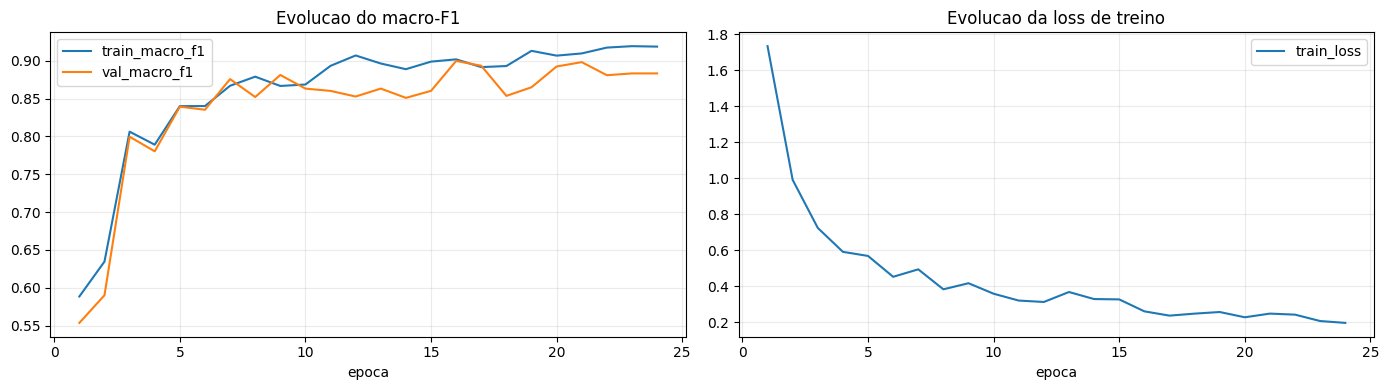

In [5]:
# O historico de treino ajuda muito a interpretar a convergencia.
history_df = pd.read_csv(lstm_summary.history_path)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
axes[0].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
axes[0].set_title("Evolucao do macro-F1")
axes[0].set_xlabel("epoca")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[1].set_title("Evolucao da loss de treino")
axes[1].set_xlabel("epoca")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## Avaliacao do melhor checkpoint

Depois do treino, carregamos o melhor modelo salvo e avaliamos em:

- validacao, para confirmar o checkpoint;
- teste, para medir generalizacao fora da amostra.

In [6]:
lstm_model = load_lstm_classifier(lstm_summary.config_path)

val_pred = predict_lstm_classes(lstm_model, val_arrays["X_seq"])
test_pred = predict_lstm_classes(lstm_model, test_arrays["X_seq"])

val_eval = evaluate_predictions(val_arrays["y"], val_pred, class_labels=bundle.class_labels)
test_eval = evaluate_predictions(test_arrays["y"], test_pred, class_labels=bundle.class_labels)

comparison_df = build_metrics_table(
    {
        "lstm_validation": val_eval,
        "lstm_test": test_eval,
    }
)
comparison_df

,modelo,accuracy,macro_f1,balanced_accuracy
0,lstm_validation,0.925150,0.899706,0.910092
1,lstm_test,0.910448,0.896413,0.919120


In [7]:
# Aqui reunimos os numeros mais importantes em um formato
# mais interpretavel para leitura academica.
best_history_row = history_df.loc[history_df["epoch"] == lstm_summary.best_epoch].iloc[0]
metrics_focus_df = pd.DataFrame(
    {
        "etapa": ["validacao", "teste"],
        "accuracy": [val_eval["accuracy"], test_eval["accuracy"]],
        "macro_f1": [val_eval["macro_f1"], test_eval["macro_f1"]],
        "balanced_accuracy": [
            val_eval["balanced_accuracy"],
            test_eval["balanced_accuracy"],
        ],
    }
)
display(metrics_focus_df)

generalization_df = pd.DataFrame(
    {
        "indicador": [
            "melhor epoca",
            "macro_f1_treino_na_melhor_epoca",
            "macro_f1_validacao_na_melhor_epoca",
            "gap_treino_validacao",
        ],
        "valor": [
            int(lstm_summary.best_epoch),
            float(best_history_row["train_macro_f1"]),
            float(best_history_row["val_macro_f1"]),
            float(best_history_row["train_macro_f1"] - best_history_row["val_macro_f1"]),
        ],
    }
)
display(generalization_df)

,etapa,accuracy,macro_f1,balanced_accuracy
0,validacao,0.925150,0.899706,0.910092
1,teste,0.910448,0.896413,0.919120


,indicador,valor
0,melhor epoca,16.000000
1,macro_f1_treino_na_melhor_epoca,0.901810
2,macro_f1_validacao_na_melhor_epoca,0.899706
3,gap_treino_validacao,0.002104


In [8]:
# Exportamos os resultados para que o notebook das baselines
# possa carregar as metricas da LSTM depois.
export_evaluation_artifacts(val_eval, LSTM_OUTPUT_DIR, "lstm_validation")
export_evaluation_artifacts(test_eval, LSTM_OUTPUT_DIR, "lstm_test")

# Relatorio detalhado por classe no conjunto de teste.
display(test_eval["classification_report_df"])

,label,precision,recall,f1-score,support
0,0,0.986111,0.797753,0.881988,89.000000
1,1,0.950000,0.950000,0.950000,20.000000
2,2,0.625000,1.000000,0.769231,5.000000
3,3,0.789474,0.937500,0.857143,16.000000
4,4,0.720588,0.942308,0.816667,52.000000
5,5,0.985294,0.985294,0.985294,68.000000
6,6,1.000000,1.000000,1.000000,33.000000
7,7,0.857143,0.857143,0.857143,7.000000
8,8,1.000000,0.785714,0.880000,14.000000
9,9,1.000000,0.935484,0.966667,31.000000


In [9]:
# Para enxergar melhor onde a rede foi bem e onde teve dificuldade,
# separamos apenas as linhas das classes reais.
per_class_test_df = (
    test_eval["classification_report_df"]
    .loc[lambda df: df["label"].astype(str).isin([str(label) for label in bundle.class_labels])]
    .copy()
)
per_class_test_df["label"] = per_class_test_df["label"].astype(int)
per_class_test_df = per_class_test_df.sort_values(["f1-score", "recall", "precision"])
display(per_class_test_df)

,label,precision,recall,f1-score,support
2,2,0.625000,1.000000,0.769231,5.0
4,4,0.720588,0.942308,0.816667,52.0
7,7,0.857143,0.857143,0.857143,7.0
3,3,0.789474,0.937500,0.857143,16.0
8,8,1.000000,0.785714,0.880000,14.0
0,0,0.986111,0.797753,0.881988,89.0
1,1,0.950000,0.950000,0.950000,20.0
9,9,1.000000,0.935484,0.966667,31.0
5,5,0.985294,0.985294,0.985294,68.0
6,6,1.000000,1.000000,1.000000,33.0


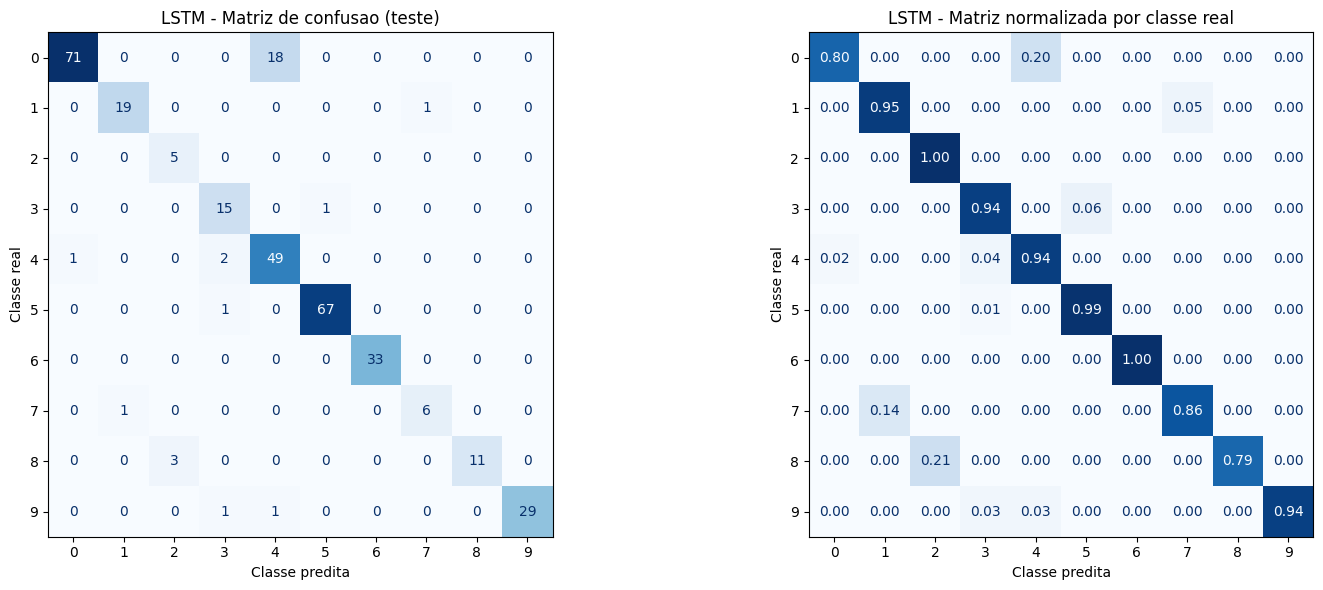

In [10]:
# Duas matrizes: uma absoluta e outra normalizada.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
    normalize=None,
    title="LSTM - Matriz de confusao (teste)",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
    normalize="true",
    title="LSTM - Matriz normalizada por classe real",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

In [11]:
# Esta celula imprime uma leitura textual com os numeros reais do experimento.
weakest_rows = per_class_test_df.head(3)

print("Leitura interpretativa da LSTM")
print()
print(
    f"No conjunto de teste, a LSTM atingiu accuracy = {test_eval['accuracy']:.4f}, "
    f"macro-F1 = {test_eval['macro_f1']:.4f} e balanced accuracy = {test_eval['balanced_accuracy']:.4f}."
)
print(
    f"A melhor epoca foi a {int(lstm_summary.best_epoch)}, com macro-F1 de validacao "
    f"igual a {val_eval['macro_f1']:.4f}."
)
print(
    f"O gap entre macro-F1 de treino e validacao na melhor epoca foi de "
    f"{best_history_row['train_macro_f1'] - best_history_row['val_macro_f1']:.4f}, "
    "o que sugere alguma diferenca entre ajuste e generalizacao, mas nao um sobreajuste explosivo."
)
print()
print("As classes com menor F1 no teste foram:")
for _, row in weakest_rows.iterrows():
    print(
        f"- classe {int(row['label'])}: precision = {row['precision']:.4f}, "
        f"recall = {row['recall']:.4f}, f1 = {row['f1-score']:.4f}, support = {int(row['support'])}"
    )
print()
print(
    "Em termos didaticos, isso indica que a rede aprendeu bem o problema como um todo, "
    "mas ainda encontra dificuldade em classes mais raras ou com assinaturas temporais "
    "mais proximas entre si."
)

Leitura interpretativa da LSTM

No conjunto de teste, a LSTM atingiu accuracy = 0.9104, macro-F1 = 0.8964 e balanced accuracy = 0.9191.
A melhor epoca foi a 16, com macro-F1 de validacao igual a 0.8997.
O gap entre macro-F1 de treino e validacao na melhor epoca foi de 0.0021, o que sugere alguma diferenca entre ajuste e generalizacao, mas nao um sobreajuste explosivo.

As classes com menor F1 no teste foram:
- classe 2: precision = 0.6250, recall = 1.0000, f1 = 0.7692, support = 5
- classe 4: precision = 0.7206, recall = 0.9423, f1 = 0.8167, support = 52
- classe 7: precision = 0.8571, recall = 0.8571, f1 = 0.8571, support = 7

Em termos didaticos, isso indica que a rede aprendeu bem o problema como um todo, mas ainda encontra dificuldade em classes mais raras ou com assinaturas temporais mais proximas entre si.


## Leitura didatica dos resultados

Ao interpretar o desempenho da `LSTM`, pense nas perguntas abaixo:

1. O `macro-F1` esta muito abaixo da `accuracy`?
   Isso pode indicar que a rede acerta bem as classes grandes, mas erra as raras.
2. A `balanced accuracy` esta coerente com o `macro-F1`?
   Isso ajuda a avaliar se o desempenho esta mais equilibrado entre as classes.
3. Quais classes a matriz de confusao mais mistura?
   Esse ponto e central para diagnostico do modelo.

A pergunta central da `versao7` agora fica bem definida: a maior profundidade da arquitetura foi suficiente para reduzir a diferenca em relacao ao `RandomForest`? No notebook seguinte, vamos responder isso diretamente.